In [1]:
from operator import add
from typing import List, TypedDict, Optional, Annotated, Dict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

In [24]:
import getpass
import os

from pydantic import BaseModel, Json, Field
from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver.from_conn_string(":memory:")

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Sales Research Agent"

from typing import Annotated, List
import operator

from langchain_community.document_loaders import WebBaseLoader
# from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

# tavily_tool = TavilySearchResults(max_results=5)

class ProfilePost(BaseModel):
    post:str
    postUrl: str
    likeCount:str
    postedDate: str


class UserProfile(BaseModel):

    username: str
    summary: str
    firstName:str
    lastName: str
    headline: str
    currentPos:str
    posts: List[ProfilePost]


class IdealProfile(BaseModel):

    industry: str = Field(..., description="Industry of the lead's company")
    company_size: Optional[str] = Field(..., description="Number of employees in the lead's company")
    revenue: Optional[str] = Field(None, description="Annual revenue of the lead's company in millions")
    job_title: str = Field(..., description="Job title of the lead")

class InputLeadData(BaseModel):
    
    lead_source: Optional[str]
    download_marketing_material: Optional[bool]
    demo_requested: Optional[bool]
    referral_partner_introduction:Optional[bool]
    project_urgency: Optional[int]  #1-3 based on urgency(1 being lowest)

# def LeadScoring(BaseModel):


class AgentState(TypedDict):
    linkedin_url:str
    website:str
    ideal_profile:IdealProfile
    input_lead_data:InputLeadData
    user_profile_details:Annotated[str,operator.add]
    scraped_website_content:Annotated[str, operator.add]
    user_profile_analysis: Annotated[str, operator.add]
    website_analysis: Annotated[str, operator.add]
    lead_extracted_data:Annotated[str,operator.add]
    sales_research_report:Annotated[str,operator.add]
    lead_score_analysis:Annotated[str,operator.add]

    # companyProfile: 

def collector(state:AgentState):
    print("WEBSITE COLLECTOR ", state["website"])
    return {"linkedin_url":state["linkedin_url"], "website":state["website"]}

def should_enrich_linkedin(state:AgentState):
    linkedin_profile= state["linkedin_url"]
    
    print("should enrich called" , linkedin_profile)
    if len(linkedin_profile)==0:
        return "enrich_linkedin"
    else:
        return "profile_fetcher"
    
def should_enrich_website(state:AgentState):

    website=state["website"]
    if len(website)==0:
        return "enrich_website"
    else:
        return "website_scraper"

#scrape webpages node
def scrape_webpages(state:AgentState) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    print("website " , state["website"])

    website= state["website"]
    # we could not find website
    if len(website)==0:
        return {"scraped_website_content", "Could not scrape empty website"}


    loader = WebBaseLoader(state["website"])

    docs = loader.load()
    print("docs", docs)
    scraped_content= "\n\n".join(
        [
            f'{doc.page_content}'
            for doc in docs
        ]
    )
    return {"scraped_website_content": scraped_content}


def enrich_linkedin(state:AgentState):

    return {"linkedin_url": "https://www.linkedin.com/in/pavankumar34/"} #should change

def enrich_website(state:AgentState):
    # return {"website":"https://innovizeai.com"} #should change

    #get website from work email
    email_id= state["email_id"]

    validate_email_regex= r"^(?!.*@(gmail\.com|hotmail\.com|yahoo\.com|outlook\.com|aol\.com|icloud\.com|mail\.com|zoho\.com|protonmail\.com|yandex\.com)).*@([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})$"


    if len(email_id)==0:

        return {"website":""} #should change
    else:
        import re

        email = email_id
        match = re.match(validate_email_regex, email)

        if match:
            domain = match.group(1)

            url = f"https://{domain}"
            print(f"Work domain: {domain}")
            return {"website": url}
        else:
           
            return {"website":""}

#analyze linked_in node
def get_linkedin_data(state: AgentState):
    """Used to analyze a linkedin user profile and create summary of profile posts etc"""

    import requests
    import json

    profile_url = "https://linkedin-api8.p.rapidapi.com/get-profile-data-by-url"
    

    querystring = {"url":state["linkedin_url"]}

    headers = {
        "x-rapidapi-key": "9958411ebcmsh66b1d9ce41707e2p1f8b93jsncb08b597fba0",
        "x-rapidapi-host": "linkedin-api8.p.rapidapi.com"
    }

    response = requests.get(profile_url, headers=headers, params=querystring)

    profile_details= response.json()

    print(response.json())

    posts_url = "https://linkedin-api8.p.rapidapi.com/get-profile-posts"

    querystring = {"username":profile_details["username"]}

    response = requests.get(posts_url, headers=headers, params=querystring)

    profile_posts= response.json()

    profile_posts= profile_posts["data"][:5] #get latest 3 posts

    # return profile data ans posts
    posts_dict={"posts":profile_posts}
    

    merged_json = merge_json(profile_details.copy(), posts_dict)

    return {"user_profile_details": json.dumps(merged_json)}

def merge_json(json1, json2):
    for key, value in json2.items():
        if key in json1 and isinstance(json1[key], dict) and isinstance(value, dict):
            merge_json(json1[key], value)
        else:
            json1[key] = value
    return json1

LINKEDIN_ANALYZER_PROMPT='''you are expert linkedin post analyser and you are tasked to analyze each linkedin profile and posts provided below and 
summarize in about 250 words and find patterns in the post. 
The number of summaries must match the number of posts provided.
For each post provide a summary of the post in this format
 """{ post_title:" ",      
        summary:" ",
        posted_date: "date"}"""
'''

def linkedin_profile_analyzer(state:AgentState):

    messages = [
        SystemMessage(content=LINKEDIN_ANALYZER_PROMPT), 
        HumanMessage(content=state['user_profile_details'])
    ]
    
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response = model.invoke(messages)
    return {"user_profile_analysis":response.content}

WEBSITE_ANALYZER_PROMPT='''you are an expert google search researcher in analyzing the scraped website content and
                         your are tasked to identify the details of the company from the website, such as industry, customers,
                        industry painpoints, their product or service offerings.
                        The output should be in a json format:
                        Example: {"summary":"",    "industry":"","painpoints":"","products/services":"" }  
                        ##IMPORTANT
                        If you cannot infer any of the the details mention them as not available, just don't make any assumptions.
                        Remember, your analysis should be based solely on the data provided for the scraped content. 
                        Please refrain from speculating or making assumptions. Your task is to provide factual and verifiable information.
                        '''

def website_analyzer(state: AgentState):
     
    messages = [
        SystemMessage(content=WEBSITE_ANALYZER_PROMPT), 
        HumanMessage(content=state['scraped_website_content'])
    ]
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response = model.invoke(messages)
    return {"website_analysis":response.content}

     
LEAD_SCORER_SYSTEM_PROMPT= '''

You are a lead scoring assistant designed to analyze leads based on specific attributes such as demographic fit, engagement, sales readiness, and timing. Your task is to evaluate each lead by calculating a total lead score and providing a brief analysis with recommendations.

The ideal_customer profile is present in {content} as json . Use this to get necessary details. 
  

The lead scoring follows these criteria:

1. **Demographic Fit (Industry, Company Size, Revenue, Job Title)**:
   - Industry: Is the lead in a target industry? (Yes: +20 points, No: +0 points)
   - Company Size: Does the company have the ideal number of employees? (Ideal range: +15 points, Medium: +10 points, Small or Large: +0 points)
   - Revenue: Does the company meet the revenue target? (Above $10M: +15 points, Below: +0 points)
   - Job Title: Is the lead a decision-maker or influencer? (Decision Maker: +25 points, Influencer: +15 points, Non-decision-maker: +0 points)

2. **Engagement (Website Visits, Content Interaction, Demo Request, Social Media)**:
   - Website Visits: Has the lead visited the website multiple times or high-value pages? (Multiple visits: +10 points, High-value pages: +10 points, Single visit: +5 points)
   - Content Interaction: Has the lead engaged with content (e.g., downloaded eBooks, attended webinars)? (Yes: +15 points, No: +0 points)
   - Demo Request: Has the lead requested a demo or filled out a contact form? (Demo request: +25 points, Contact form: +20 points)
   - Social Media Engagement: Has the lead engaged with social media content (e.g., liked, commented, shared)? (Yes: +5 points, No: +0 points)

3. **Sales Readiness (Buying Stage, Recent Activity)**:
   - Buying Stage: Is the lead in the awareness, consideration, or decision stage? (Decision: +35 points, Consideration: +25 points, Awareness: +10 points)
   - Recent Activity: Has the lead recently engaged with the company (e.g., responded to emails, attended webinars)? (Yes: +25 points, No: +0 points)

4. **Lead Source (Referral, Inbound Marketing, Paid Ads, Cold Outreach)**:
   - Referral or Partner Introduction: Did the lead come through a referral? (Yes: +30 points, No: +0 points)
   - Inbound Marketing: Did the lead come through inbound marketing efforts? (Yes: +20 points, No: +0 points)
   - Paid Ad Click: Did the lead click on a paid advertisement? (Yes: +15 points, No: +0 points)
   - Cold Outreach: Was the lead generated via cold outreach? (Yes: +10 points, No: +0 points)

5. **Timing (Purchase Timeline, Project Urgency)**:
   - Purchase Timeline: Is the lead ready to buy within the next 3 months? (3 months: +20 points, 6 months: +10 points, 6+ months: +5 points)
   - Project Urgency: Does the lead have high urgency to find a solution? (High: +15 points, Medium: +10 points, Low: +0 points)

you will receive data in this format:

- Industry: Technology  
- Company Size: 250 employees  
- Revenue: $50.5M  
- Job Title: CTO  
- Website Visits: 3  
- Visited High-Value Pages: Yes  
- Content Interaction: Yes (Downloaded eBook, Attended Webinar)  
- Demo Request: Yes  
- Form Submission: No  
- Social Media Engagement: No  
- Recent Activity: Yes  
- Buying Stage: Consideration  
- Referral Partner Introduction: No  
- Inbound Marketing: Yes  
- Paid Ad Click: No  
- Cold Outreach: No  
- Purchase Timeline: 3 months  
- Project Urgency: High  
   
When you receive lead details, you will:
1. Calculate the total lead score based on the criteria.
2. Provide an analysis explaining why the lead received that score.
3. Offer recommendations on how to engage the lead, including potential next steps.


##IMPORTANT
            If you cannot infer any of the the details mention them as not available and give a score of 0, just don't make any assumptions.
            Remember, your analysis should be based solely on the data provided. 
            Please refrain from speculating or making assumptions. Your task is to extract factual and verifiable information.


'''

LEAD_DATA_EXTRACTOR_PROMPT='''

You are a data extraction assistant tasked with extracting specific details from data present in different json's as text related to leads. Your goal is to analyze the provided string and extract the data in the below structure:

Here are the details of a lead to be extracted:

- Industry: Technology  
- Company Size: 250 employees  
- Revenue: $50.5M  
- Job Title: CTO  
- Website Visits: 3  
- Visited High-Value Pages: Yes  
- Content Interaction: Yes (Downloaded eBook, Attended Webinar)  
- Demo Request: Yes  
- Form Submission: No  
- Social Media Engagement: No  
- Recent Activity: Yes  
- Buying Stage: Consideration  
- Referral Partner Introduction: No  
- Inbound Marketing: Yes  
- Paid Ad Click: No  
- Cold Outreach: No  
- Purchase Timeline: 3 months  
- Project Urgency: High  

  ##IMPORTANT
            If you cannot infer any of the the details mention them as not available , just don't make any assumptions.
            Remember, your analysis should be based solely on the data provided for the scraped content. 
            Please refrain from speculating or making assumptions. Your task is to extract factual and verifiable information.

'''


def lead_data_extractor(state:AgentState):
    #lead data as json
    user_profile_analysis= state['user_profile_analysis']
    website_analysis=state["website_analysis"]
    input_lead_data= state["input_lead_data"]

    lead_data_json=  input_lead_data.json()

    lead_data=  user_profile_analysis + " " + website_analysis + " " + lead_data_json

    messages = [
        SystemMessage(content= LEAD_DATA_EXTRACTOR_PROMPT),
        HumanMessage(content= lead_data)
    ]

    llm= ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response= llm.invoke(messages)


    return {"lead_extracted_data": response.content}


def lead_scorer(state:AgentState):

    lead_extracted_data= state["lead_extracted_data"]

    content= state["ideal_profile"]

    content_json= content.json()

    messages = [
        SystemMessage(content= LEAD_SCORER_SYSTEM_PROMPT.format(content= content_json)),
        HumanMessage(content= lead_extracted_data)
    ]

    llm= ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response= llm.invoke(messages)


    return {"lead_score_analysis": response.content}
    

     
REPORT_GENERATOR_PROMPT='''
    you are expert analyzer agent specialized in creating sales research report that is used by 
    sales team to reach the potential prospects. you are tasked to create a comprehensive sales research report
    consisting of every aspect required for sales team. from the information you have in

    {content}
    
    Here is a sample report structure you need to create 

       """1. Executive Summary

        Objective: Brief overview of the report's purpose.

        Key Findings: High-level insights from the analysis.

        Next Steps: Summary of recommended actions, first linkedin connection message using the above information from website and their linkedin posts and also
        a hyperpersonalized email for outbound reach. Never skip this.
        
        Important "Never Start with "I hope this message finds you well or any other greeting".
        and start with a compliment from the info you have. Never pitch the solutions in your personalized email.
        and always propose if they are interested in ebook which helps in finding high ROI potential AI use cases.But never use the word "AI" as it is becoming a buzz word.
        Never skip generating linkedin outreach message and hyperpersonalized email


        2. User Profile Analysis

        Personal Information:

        Name, title, and role within the company.

        LinkedIn profile summary, posts 

        Professional Background:

        Career history and notable achievements.

        Recent activity on LinkedIn (posts, articles, engagements).

        Network Insights:

        Mutual connections, professional groups, and shared interests.

        Pain Points and Needs:

        Inferred or explicitly stated challenges and goals.

        3. Company Overview ((Don't use company_context paragraph or company name for the below sections))

        Basic Information:

        Company name, industry, size, and location.

        Mission, vision, and core values.

        Product/Service Offerings:

        Overview of products or services offered.

        Unique selling propositions (USPs) and market differentiators.

        Company Structure: (Don't use company_context paragraph )

        Key executives and decision-makers.

        Organizational structure and departments of interest.

        Recent Company News:(Don't use company_context paragraph)

        Recent announcements, press releases, or news articles.

        Any notable events such as product launches, partnerships, or changes in leadership.

        Financial Overview:(Don't use company_context paragraph)

        Revenue, profitability, and any available financial metrics.

        Recent funding rounds, investors, and intended use of funds.

        4. Industry and Market Analysis (Don't use company_context paragraph)

        Industry Overview:

        Description of the industry and market dynamics.

        Current trends, opportunities, and challenges in the industry.

        Market Position: (Don't use company_context paragraph)

        Company’s position within the industry.

        Major competitors and market share analysis.

        SWOT Analysis:

        Strengths, Weaknesses, Opportunities, and Threats for the company in its market.

        Regulatory Environment:

        Any relevant regulations or industry standards that may impact the company.

        5. Competitive Landscape

        Key Competitors:

        List and brief profiles of main competitors.

        Comparative Analysis:

        Comparison of product/service offerings, market strategies, and customer base.

        Market Positioning:

        How the company is positioned relative to its competitors (e.g., pricing, features, brand image).

        6. Customer Insights

        Target Audience:

        Description of the company’s typical customer segments.

        Customer Needs:

        Insights into customer pain points, desires, and needs.

        Customer Feedback:

        Summary of customer reviews, testimonials, or case studies.

        7. Recent Developments

        Technology and Innovation:

        Any recent technological developments or innovations by the company.

        Strategic Initiatives:

        New strategies, partnerships, or initiatives the company is pursuing.

        Market Movements:

        Any mergers, acquisitions, or market exits.

        8. Sales and Marketing Strategies

        Current Sales Strategies:

        Overview of the company’s existing sales tactics and channels.

        Marketing Campaigns:

        Summary of recent or ongoing marketing campaigns(if any)

        Partnerships and Alliances:

        Key partnerships that influence sales and marketing efforts.
        

        9. Engagement Strategy and Recommendations

        Tailored Outreach Suggestions:

        Specific suggestions for initial contact, messaging, and value propositions.

        Conversation Starters: 

        Topics or questions that resonate with the prospect’s current situation or industry trends.

        Pain Points:

        Pain points that they face.

        Proposed Solutions:

        Custom AI or automation solutions that address identified pain points or opportunities. 
        Only suggest solutions, if you think its genuinely required,otherwise Donot suggest general solutions

        Lead Score Analysis:

         ### Total Score Calculation:
        - Demographic Fit:
        - Engagement: 
        - Sales Readiness: 
        - Lead Source: 
        - Timing: 

        Total Lead Score = 

        ### Recommendations:

        Detailed Recommendations based on Lead Score Analysis

        Follow-Up Plan:

        Timeline and content for follow-up interactions."""  
        """  
        '''
def sales_research_report_generator(state:AgentState):
    
    user_profile_analysis= state['user_profile_analysis']
    website_analysis=state["website_analysis"]
    lead_score_analysis= state["lead_score_analysis"]
    content = user_profile_analysis + " " + website_analysis + " " + lead_score_analysis
    messages = [
        SystemMessage(content=REPORT_GENERATOR_PROMPT.format(content= content))
    ]

    llm= ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response= llm.invoke(messages)

    return {"sales_research_report": response.content}


from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

from typing_extensions import TypedDict

_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

from typing import List, Optional

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph, START



builder = StateGraph(AgentState)

# add nodes to the graph
builder.add_node("collector",collector)
builder.add_node("profile_fetcher", get_linkedin_data )
builder.add_node("website_scraper", scrape_webpages)
builder.add_node("linkedin_profile_analyzer", linkedin_profile_analyzer)
builder.add_node("website_analyzer",website_analyzer)

#scores leads
builder.add_node("lead_data_extractor", lead_data_extractor)
builder.add_node("lead_scorer", lead_scorer)


builder.add_node("report_generator",sales_research_report_generator)
builder.add_node("enrich_linkedin",enrich_linkedin) #should change
builder.add_node("enrich_website", enrich_website) # should change

#set entry point
builder.set_entry_point("collector")

#add edges
# builder.add_edge("collector","profile_fetcher" )
# builder.add_edge("collector","website_scraper")
builder.add_edge("profile_fetcher", "linkedin_profile_analyzer")
builder.add_edge("website_scraper","website_analyzer")
builder.add_edge("enrich_linkedin","profile_fetcher")
builder.add_edge("enrich_website","website_scraper")
builder.add_edge("linkedin_profile_analyzer","lead_data_extractor")
builder.add_edge("website_analyzer","lead_data_extractor")
builder.add_edge("lead_data_extractor","lead_scorer")
builder.add_edge("lead_scorer","report_generator")


builder.add_conditional_edges("collector",should_enrich_linkedin)
builder.add_conditional_edges("collector",should_enrich_website)


graph= builder.compile(checkpointer=memory)

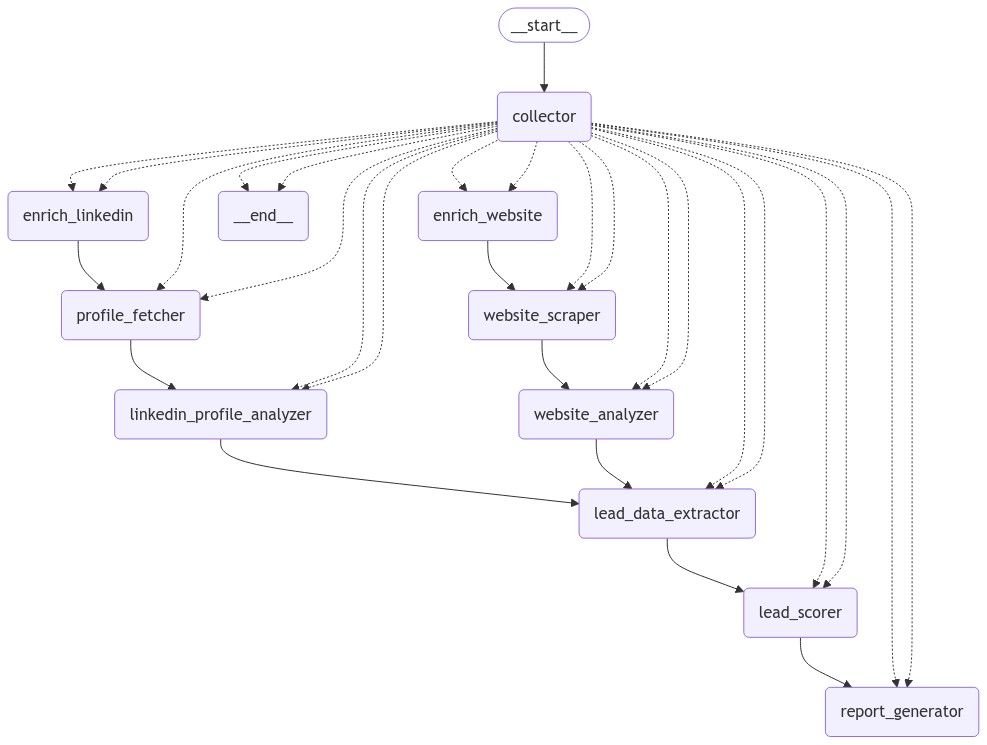

In [25]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [22]:
import uuid

In [26]:
thread = {"configurable": {"thread_id": uuid.uuid4}}

ideal_profile= IdealProfile(
    industry= "Finance",
    company_size= "10-50",
    revenue= "$10M+",
    job_title="CTO, CEO"
)

lead_captured_data= InputLeadData(
    lead_source= "inbound",
    download_marketing_material= True,
    demo_requested= False,
    referral_partner_introduction= False,
    project_urgency= 3
)

graph.invoke({
    "linkedin_url":"https://www.linkedin.com/in/joshuasilver/",
    "website":"http://www.rainforestpay.com/",
    "ideal_profile":ideal_profile,
    "input_lead_data":lead_captured_data
},thread)

WEBSITE COLLECTOR  http://www.rainforestpay.com/
should enrich called https://www.linkedin.com/in/joshuasilver/
website  http://www.rainforestpay.com/
docs [Document(metadata={'source': 'http://www.rainforestpay.com/', 'title': 'Rainforest | Payments processing for software companies', 'description': 'Embed payments into your product or platform with Rainforest’s configurable, low-code components. Accept and send payments, minimize risk and compliance headaches, and grow revenue.', 'language': 'No language found.'}, page_content='Rainforest | Payments processing for software companiesProductDevelopersPricingResourcesCompanySign InStart nowProductOverviewLearn more about our product.Use CasesMove money in multiple directions.Calculate ROIMake cost savings, boost revenue.DevelopersPricingResourcesCompanySign InStart nowPayment processing for your platformGrow revenue by embedding payments into your product — without taking on risk or compliance headaches.\nStart NowTrusted byMake money m

{'linkedin_url': 'https://www.linkedin.com/in/joshuasilver/',
 'website': 'http://www.rainforestpay.com/',
 'ideal_profile': IdealProfile(industry='Finance', company_size='10-50', revenue='$10M+', job_title='CTO, CEO'),
 'input_lead_data': InputLeadData(lead_source='inbound', download_marketing_material=True, demo_requested=False, referral_partner_introduction=False, project_urgency=3),
 'user_profile_details': '{"id": 6280909, "urn": "ACoAAABf1s0Ba6zSfI5baexpBsdVYHQ7g9TjgU4", "username": "joshuasilver", "firstName": "Joshua", "lastName": "Silver", "isCreator": false, "isOpenToWork": false, "isHiring": false, "profilePicture": "https://media.licdn.com/dms/image/v2/D5603AQHf4RnwlYMqkg/profile-displayphoto-shrink_800_800/profile-displayphoto-shrink_800_800/0/1670209153426?e=1734566400&v=beta&t=5s4uCeLBVOSjzwwz_4lGdgEuDagDWnosec2meibD_Pg", "backgroundImage": null, "summary": "I\\u2019ve spent my entire career in embedded payments. Early on, I co-founded Patientco (exited to Waystar) and t